---
## Section 1 — Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import warnings
import logging
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Plotting style
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

logger.info('Libraries loaded successfully.')
print('All libraries imported successfully.')

2026-06-01 03:13:06,457 - INFO - Libraries loaded successfully.


All libraries imported successfully.


---
## Section 2 — Data Ingestion

In [2]:
FILE_PATH = '../data/raw/USECASE_-_Data_Engineering.xlsx'

try:
    product_details = pd.read_excel(FILE_PATH, sheet_name='product_details')
    retail_data1    = pd.read_excel(FILE_PATH, sheet_name='retail_data1')
    retail_data2    = pd.read_excel(FILE_PATH, sheet_name='retail_data2')
    logger.info('All three datasets ingested successfully.')
    print('Data ingested successfully.')
except Exception as e:
    logger.error(f'Ingestion failed: {e}')
    raise

print(f'\nproduct_details : {product_details.shape}')
print(f'retail_data1    : {retail_data1.shape}')
print(f'retail_data2    : {retail_data2.shape}')

2026-06-01 03:13:13,450 - INFO - All three datasets ingested successfully.


Data ingested successfully.

product_details : (10, 4)
retail_data1    : (4243, 16)
retail_data2    : (4251, 16)


In [3]:
# Preview product_details
print('=== Product Details (Dimension Table) ===')
display(product_details)

=== Product Details (Dimension Table) ===


,product_id,product_name,category,price
0,101,Laptop,Electronics,250000
1,102,Phone,Electronics,70000
2,103,Shirt,Clothing,1300
3,104,Shoes,Clothing,8000
4,105,TV,Electronics,45000
5,106,Sofa,Furniture,80000
6,107,Dining Table,Furniture,50000
7,108,Mixer Grinder,Home Appliances,15000
8,109,Refrigerator,Home Appliances,65000
9,110,Microwave,Home Appliances,45000


In [4]:
# Preview retail_data1
print('=== retail_data1 — First 5 Rows ===')
display(retail_data1.head())

=== retail_data1 — First 5 Rows ===


,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
0,1,642,Troy Mitchell,108,15000.0,Mixer grinder,Home Appliances,offline,Bangalore,2025-12-06 00:00:00,3,UPI,0.10,Troy60@gmail.com,8385276968,successful
1,2,881,Sarah Guerrero,102,70000.0,Phone,ELEC,online,Bangalore,2025-07-21 00:00:00,5,Card,0.35,SarahGuerrero@yahoo.com,7147248911,successful
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-07-11 00:00:00,2,UPI,0.05,SamanthaHull@outlook.com,7415321565,successful
3,4,794,Gerald Cooper,106,80000.0,sofa,FURN,offline,Chennai,2025-10-06 00:00:00,2,UPI,0.05,GeraldCooper@gmail.com,9739354201,successful
4,5,864,Cameron Black,108,15000.0,Mixer grinder,home appliances,offline,Chennai,2025-12-12 00:00:00,1,Cash,0.05,CameronBlack@yahoo.com,9938169477,successful


In [5]:
# Preview retail_data2
print('=== retail_data2 — First 5 Rows ===')
display(retail_data2.head())

=== retail_data2 — First 5 Rows ===


,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
0,4001,1112,Jasmine Carlson,106,80000.0,sofa,Furniture,offline,Delhi,12-18-2025,2,Cash,0.10,JasmineCarlson@gmail.com,8286662057,successful
1,4002,1125,Jeanne Suarez,105,45000.0,Tv,Electronics,online,Mumbai,2025-08-07 00:00:00,3,Card,0.10,JeanneSuarez@yahoo.com,6435924212,successful
2,4003,1379,Anthony Howard,107,50000.0,Dining table,FURN,offline,Delhi,09-19-2025,2,Cash,0.30,Anthony42@gmail.com,8187928333,successful
3,4004,1570,John Wilkins,107,50000.0,DINING TABLE,FURN,offline,Delhi,2025-11-20 00:00:00,2,Cash,0.40,JohnWilkins@outlook.com,6440039629,successful
4,4005,1433,Joseph Knapp,108,15000.0,Mixer grinder,home appliances,online,Bangalore,2025-09-29 00:00:00,5,Cash,0.25,JosephKnapp@gmail.com,9284221237,successful


---
## Section 3 — Exploratory Data Analysis (EDA)
Understanding the structure, quality, and distribution of the raw data before any transformations.

In [6]:
# EDA — Data Quality Report
def eda_report(df, name):
    print(f"\n{'='*55}")
    print(f"  EDA Report: {name}")
    print(f"{'='*55}")
    print(f"Shape           : {df.shape}")
    print(f"Duplicate Rows  : {df.duplicated().sum()}")
    print(f"\nMissing Values:")
    print(df.isnull().sum())
    print(f"\nData Types:")
    print(df.dtypes)

eda_report(retail_data1, 'retail_data1')
eda_report(retail_data2, 'retail_data2')


  EDA Report: retail_data1
Shape           : (4243, 16)
Duplicate Rows  : 0

Missing Values:
transaction_id         0
customer_id            0
customer_name          0
product_id             0
price                404
product_name           0
category               0
purchase_location      0
city                   0
transaction_date       0
quantity               0
payment_method         0
discount               0
email                  0
phone                  0
payment_status         0
dtype: int64

Data Types:
transaction_id         int64
customer_id            int64
customer_name         object
product_id             int64
price                float64
product_name          object
category              object
purchase_location     object
city                  object
transaction_date      object
quantity               int64
payment_method        object
discount             float64
email                 object
phone                  int64
payment_status        object
dtype: object

 

In [7]:
# ---- Inconsistent category values ----
print('Unique categories in retail_data1:')
print(retail_data1['category'].unique())

print('\nUnique categories in retail_data2:')
print(retail_data2['category'].unique())

Unique categories in retail_data1:
['Home Appliances' 'ELEC' 'FURN' 'home appliances' 'Electronics'
 'electronics' 'CLOTH' 'clothing' 'Clothing' 'furniture' 'Furniture'
 'HOME']

Unique categories in retail_data2:
['Furniture' 'Electronics' 'FURN' 'home appliances' 'electronics' 'HOME'
 'CLOTH' 'Home Appliances' 'furniture' 'Clothing' 'ELEC' 'clothing']


In [8]:
# ---- Invalid quantity records ----
print('retail_data1:')
print(f'  Negative quantity rows : {(retail_data1["quantity"] < 0).sum()}')
print(f'  Zero quantity rows     : {(retail_data1["quantity"] == 0).sum()}')

print('\nretail_data2:')
print(f'  Negative quantity rows : {(retail_data2["quantity"] < 0).sum()}')
print(f'  Zero quantity rows     : {(retail_data2["quantity"] == 0).sum()}')

retail_data1:
  Negative quantity rows : 34
  Zero quantity rows     : 16

retail_data2:
  Negative quantity rows : 31
  Zero quantity rows     : 12


In [9]:
# ---- Mixed date format samples ----
print('Sample transaction_date values (retail_data1):')
print(retail_data1['transaction_date'].head(20).tolist())

Sample transaction_date values (retail_data1):
[datetime.datetime(2025, 12, 6, 0, 0), datetime.datetime(2025, 7, 21, 0, 0), datetime.datetime(2025, 7, 11, 0, 0), datetime.datetime(2025, 10, 6, 0, 0), datetime.datetime(2025, 12, 12, 0, 0), datetime.datetime(2025, 7, 25, 0, 0), datetime.datetime(2025, 7, 25, 0, 0), datetime.datetime(2026, 3, 3, 0, 0), '02-19-2026', datetime.datetime(2025, 8, 30, 0, 0), datetime.datetime(2025, 12, 16, 0, 0), datetime.datetime(2025, 12, 15, 0, 0), '06-30-2025', datetime.datetime(2025, 6, 14, 0, 0), datetime.datetime(2026, 2, 24, 0, 0), datetime.datetime(2026, 1, 31, 0, 0), '08-20-2025', datetime.datetime(2025, 5, 19, 0, 0), '05-15-2025', datetime.datetime(2025, 9, 7, 0, 0)]


In [10]:
# ---- Payment status distribution ----
print('Payment Status — retail_data1:')
print(retail_data1['payment_status'].value_counts())

print('\nPayment Status — retail_data2:')
print(retail_data2['payment_status'].value_counts())

Payment Status — retail_data1:
successful    4000
failed         243
Name: payment_status, dtype: int64

Payment Status — retail_data2:
successful    4000
failed         251
Name: payment_status, dtype: int64


### EDA Summary — Data Quality Issues Found

| Issue | retail_data1 | retail_data2 |
|---|---|---|
| Missing prices | 404 rows | 405 rows |
| Negative quantity | 34 rows | 31 rows |
| Zero quantity | 16 rows | 12 rows |
| Inconsistent category names | 12 variations | same |
| Mixed date formats | Excel serial + MM-DD-YYYY | same |
| Duplicate transaction IDs (failed payments) | Present | Present |
| PII columns (email, phone) | Present | Present |

---
## Section 4 — Data Merging
Combining both retail transaction datasets from the two source systems into a single unified dataset.

In [11]:
# COMBINE BOTH SOURCE DATASETS

# Tag each record with its source before merging
retail_data1['source'] = 'retail_data1'
retail_data2['source'] = 'retail_data2'

raw_combined = pd.concat([retail_data1, retail_data2], ignore_index=True)

logger.info(f'Combined dataset shape: {raw_combined.shape}')
print(f'Combined dataset: {raw_combined.shape[0]} rows, {raw_combined.shape[1]} columns')

2026-06-01 03:13:35,097 - INFO - Combined dataset shape: (8494, 17)


Combined dataset: 8494 rows, 17 columns


---
## Section 5 — Data Cleaning & Transformation
Applying all preprocessing steps to produce a clean, reliable dataset.

In [12]:
# Work on a copy to preserve the raw data
df = raw_combined.copy()
print(f'Starting shape: {df.shape}')

Starting shape: (8494, 17)


In [13]:
# 5.1 — Remove Failed Payment Records
# Assumption: Same transaction_id appearing with 'failed' payment_status represents a failed payment retry.
# Only 'successful' transactions are valid for analytics.

before = len(df)
df = df[df['payment_status'] == 'successful'].copy()
after = len(df)

logger.info(f'Removed {before - after} failed payment records.')
print(f'Failed payments removed: {before - after} rows dropped.')
print(f'Remaining rows: {len(df)}')

2026-06-01 03:13:40,226 - INFO - Removed 494 failed payment records.


Failed payments removed: 494 rows dropped.
Remaining rows: 8000


In [14]:
# 5.2 — Remove Full Duplicate Rows

before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

logger.info(f'Removed {before - after} duplicate rows.')
print(f'Duplicates removed: {before - after} rows dropped.')
print(f'Remaining rows: {len(df)}')

2026-06-01 03:13:41,962 - INFO - Removed 0 duplicate rows.


Duplicates removed: 0 rows dropped.
Remaining rows: 8000


In [15]:
# 5.3 — Fix Mixed Date Formats
# Two date formats observed:
#   - Excel serial numbers (e.g., 45997)
#   - String dates (e.g., '02-19-2026' in MM-DD-YYYY format)
# Both are converted to standard datetime format.

def parse_mixed_dates(val):
    if isinstance(val, (int, float)):
        try:
            return pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(val))
        except:
            return pd.NaT
    elif isinstance(val, str):
        try:
            return pd.to_datetime(val, format='%m-%d-%Y')
        except:
            return pd.NaT
    elif isinstance(val, datetime):
        return pd.Timestamp(val)
    else:
        return pd.NaT

df['transaction_date'] = df['transaction_date'].apply(parse_mixed_dates)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

null_dates = df['transaction_date'].isnull().sum()
logger.info(f'Date parsing complete. Null dates remaining: {null_dates}')
print(f'Date formats standardized. Null dates remaining: {null_dates}')
print(f'Sample dates after fix:')
print(df['transaction_date'].head(5).tolist())

2026-06-01 03:13:53,917 - INFO - Date parsing complete. Null dates remaining: 0


Date formats standardized. Null dates remaining: 0
Sample dates after fix:
[Timestamp('2025-12-06 00:00:00'), Timestamp('2025-07-21 00:00:00'), Timestamp('2025-07-11 00:00:00'), Timestamp('2025-10-06 00:00:00'), Timestamp('2025-12-12 00:00:00')]


In [16]:
# 5.4 — Fill Missing Prices from product_details
# Assumption: Where price is missing in transaction data,
# the standard price from the product dimension table is used.

price_map = product_details.set_index('product_id')['price'].to_dict()

df['price'] = df.apply(
    lambda row: price_map.get(row['product_id'], row['price'])
    if pd.isnull(row['price']) else row['price'],
    axis=1
)

remaining_null = df['price'].isnull().sum()
logger.info(f'Missing prices filled. Remaining nulls: {remaining_null}')
print(f'Missing prices filled from product_details. Remaining nulls: {remaining_null}')

2026-06-01 03:13:57,558 - INFO - Missing prices filled. Remaining nulls: 0


Missing prices filled from product_details. Remaining nulls: 0


In [17]:
# 5.5 — Remove Invalid Quantity Records
# Assumption: Rows with quantity <= 0 are invalid entries.
# Negative quantities likely represent erroneous return entries.
# Zero quantities represent incomplete/cancelled transactions.

before = len(df)
df = df[df['quantity'] > 0].copy()
after = len(df)

logger.info(f'Removed {before - after} rows with quantity <= 0.')
print(f'Invalid quantity rows removed: {before - after} rows dropped.')
print(f'Remaining rows: {len(df)}')

2026-06-01 03:14:00,286 - INFO - Removed 86 rows with quantity <= 0.


Invalid quantity rows removed: 86 rows dropped.
Remaining rows: 7914


In [18]:
# 5.6 — Standardize Category Names
# Multiple inconsistent variations observed:
# 'ELEC', 'electronics', 'Electronics' → 'Electronics'
# 'CLOTH', 'clothing', 'Clothing'      → 'Clothing'
# 'FURN', 'furniture', 'Furniture'     → 'Furniture'
# 'HOME', 'home appliances'            → 'Home Appliances'

category_map = {
    'ELEC'           : 'Electronics',
    'electronics'    : 'Electronics',
    'Electronics'    : 'Electronics',
    'CLOTH'          : 'Clothing',
    'clothing'       : 'Clothing',
    'Clothing'       : 'Clothing',
    'FURN'           : 'Furniture',
    'furniture'      : 'Furniture',
    'Furniture'      : 'Furniture',
    'HOME'           : 'Home Appliances',
    'home appliances': 'Home Appliances',
    'Home Appliances': 'Home Appliances',
    'HOME APPLIANCES': 'Home Appliances'
}

df['category'] = df['category'].map(category_map).fillna(df['category'])

logger.info('Category names standardized.')
print(f'Categories standardized.')
print(f'Unique categories now: {df["category"].unique()}')

2026-06-01 03:14:03,943 - INFO - Category names standardized.


Categories standardized.
Unique categories now: ['Home Appliances' 'Electronics' 'Furniture' 'Clothing']


In [19]:
# 5.7 — Standardize Product Names & Purchase Location

df['product_name']      = df['product_name'].str.title().str.strip()
df['purchase_location'] = df['purchase_location'].str.lower().str.strip()
df['customer_name']     = df['customer_name'].str.strip()
df['city']              = df['city'].str.strip()

logger.info('Product names and purchase location standardized.')
print(f'Product names standardized.')
print(f'Unique product names: {df["product_name"].unique()}')

2026-06-01 03:14:05,925 - INFO - Product names and purchase location standardized.


Product names standardized.
Unique product names: ['Mixer Grinder' 'Phone' 'Refrigerator' 'Sofa' 'Laptop' 'Microwave'
 'Shoes' 'Shirt' 'Tv' 'Dining Table']


In [20]:
# 5.8 — PII Masking (Email & Phone)
# Personally Identifiable Information is masked using
# SHA-256 hashing (first 20 characters of the hash).
# Original PII columns are dropped after masking.

def hash_pii(value):
    if pd.isnull(value):
        return None
    return hashlib.sha256(str(value).encode()).hexdigest()[:20]

df['email_masked'] = df['email'].apply(hash_pii)
df['phone_masked'] = df['phone'].astype(str).apply(hash_pii)

# Drop raw PII columns
df.drop(columns=['email', 'phone'], inplace=True)

logger.info('PII masking applied. Original email and phone columns dropped.')
print('PII masking complete. Email and phone columns hashed and originals removed.')

2026-06-01 03:14:10,662 - INFO - PII masking applied. Original email and phone columns dropped.


PII masking complete. Email and phone columns hashed and originals removed.


In [21]:
# 5.9 — Validate Discount Range
# Discount must be between 0 and 1 (0% to 100%)

invalid_discount = df[(df['discount'] < 0) | (df['discount'] > 1)]
logger.info(f'Invalid discount records found: {len(invalid_discount)}')
print(f'Invalid discount records: {len(invalid_discount)}')

df = df[(df['discount'] >= 0) & (df['discount'] <= 1)].copy()
print(f'Discount validation complete.')

2026-06-01 03:14:12,681 - INFO - Invalid discount records found: 0


Invalid discount records: 0
Discount validation complete.


In [22]:
# 5.10 — Final Cleaned Dataset Summary

print('='*55)
print('CLEANED DATASET SUMMARY')
print('='*55)
print(f'Final Shape     : {df.shape}')
print(f'Null Values     :\n{df.isnull().sum()}')
print(f'\nData Types:\n{df.dtypes}')
display(df.head())

CLEANED DATASET SUMMARY
Final Shape     : (7914, 17)
Null Values     :
transaction_id       0
customer_id          0
customer_name        0
product_id           0
price                0
product_name         0
category             0
purchase_location    0
city                 0
transaction_date     0
quantity             0
payment_method       0
discount             0
payment_status       0
source               0
email_masked         0
phone_masked         0
dtype: int64

Data Types:
transaction_id                int64
customer_id                   int64
customer_name                object
product_id                    int64
price                       float64
product_name                 object
category                     object
purchase_location            object
city                         object
transaction_date     datetime64[ns]
quantity                      int64
payment_method               object
discount                    float64
payment_status               object
source  

,transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,payment_status,source,email_masked,phone_masked
0,1,642,Troy Mitchell,108,15000.0,Mixer Grinder,Home Appliances,offline,Bangalore,2025-12-06,3,UPI,0.10,successful,retail_data1,40a175d94b67c5b13875,f896c10e8ef446251b8c
1,2,881,Sarah Guerrero,102,70000.0,Phone,Electronics,online,Bangalore,2025-07-21,5,Card,0.35,successful,retail_data1,24ebfd46331edd85d7f4,b81e246fd26ec631b6c6
2,3,505,Samantha Hull,109,65000.0,Refrigerator,Home Appliances,offline,Chennai,2025-07-11,2,UPI,0.05,successful,retail_data1,a591c2c7e3daa665f8db,ed2e661efab47124a2da
3,4,794,Gerald Cooper,106,80000.0,Sofa,Furniture,offline,Chennai,2025-10-06,2,UPI,0.05,successful,retail_data1,48f7c7da0f1149d18db2,73d5419d755c2d3f4e14
4,5,864,Cameron Black,108,15000.0,Mixer Grinder,Home Appliances,offline,Chennai,2025-12-12,1,Cash,0.05,successful,retail_data1,f842de5fc6e0b75b586d,bcd6f7547010985038f9


---
## Section 6 — Feature Engineering & KPI Calculation

In [23]:
# FEATURE ENGINEERING

# Revenue = price * quantity * (1 - discount)
df['revenue'] = (df['price'] * df['quantity'] * (1 - df['discount'])).round(2)

# Date-based features
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['month_name']  = df['transaction_date'].dt.strftime('%b')
df['quarter']     = df['transaction_date'].dt.quarter
df['day_of_week'] = df['transaction_date'].dt.day_name()
df['is_weekend']  = df['day_of_week'].isin(['Saturday', 'Sunday'])

logger.info('Feature engineering complete.')
print('Features engineered: revenue, year, month, quarter, day_of_week, is_weekend')

2026-06-01 03:14:21,852 - INFO - Feature engineering complete.


Features engineered: revenue, year, month, quarter, day_of_week, is_weekend


In [24]:
# CORE KPIs

total_revenue      = df['revenue'].sum()
total_transactions = df['transaction_id'].nunique()
total_customers    = df['customer_id'].nunique()
avg_order_value    = df['revenue'].mean()
avg_discount       = df['discount'].mean()
total_units_sold   = df['quantity'].sum()

print('='*55)
print('KEY BUSINESS KPIs')
print('='*55)
print(f'  Total Revenue          : ₹{total_revenue:,.2f}')
print(f'  Total Transactions     : {total_transactions:,}')
print(f'  Total Unique Customers : {total_customers:,}')
print(f'  Average Order Value    : ₹{avg_order_value:,.2f}')
print(f'  Average Discount       : {avg_discount*100:.1f}%')
print(f'  Total Units Sold       : {total_units_sold:,}')
print('='*55)

KEY BUSINESS KPIs
  Total Revenue          : ₹1,163,993,285.00
  Total Transactions     : 7,914
  Total Unique Customers : 1,960
  Average Order Value    : ₹147,080.27
  Average Discount       : 22.4%
  Total Units Sold       : 23,596


In [25]:
# ---- Revenue by Category ----
rev_by_category = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
rev_by_category.columns = ['Category', 'Total Revenue']
print('Revenue by Category:')
display(rev_by_category)

Revenue by Category:


,Category,Total Revenue
0,Electronics,674462500.0
1,Furniture,243413000.0
2,Home Appliances,229025250.0
3,Clothing,17092535.0


In [26]:
# ---- Revenue by City ----
rev_by_city = (
    df.groupby('city')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
rev_by_city.columns = ['City', 'Total Revenue']
print('Revenue by City:')
display(rev_by_city)

Revenue by City:


,City,Total Revenue
0,Chennai,246028300.0
1,Delhi,242022530.0
2,Hyderabad,232881480.0
3,Mumbai,226340465.0
4,Bangalore,216720510.0


In [27]:
# ---- Monthly Revenue Trend ----
rev_by_month = (
    df.groupby(['year', 'month', 'month_name'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)
print('Monthly Revenue Trend:')
display(rev_by_month)

Monthly Revenue Trend:


,year,month,month_name,revenue
0,2025,1,Jan,9342250.0
1,2025,2,Feb,6064440.0
2,2025,3,Mar,7949055.0
3,2025,4,Apr,57418535.0
4,2025,5,May,96635265.0
5,2025,6,Jun,92879965.0
6,2025,7,Jul,91364460.0
7,2025,8,Aug,99959810.0
8,2025,9,Sep,97668850.0
9,2025,10,Oct,96595110.0


In [28]:
# ---- Top Products ----
top_products = (
    df.groupby('product_name')
    .agg(
        Total_Revenue=('revenue', 'sum'),
        Units_Sold=('quantity', 'sum'),
        Transactions=('transaction_id', 'count')
    )
    .sort_values('Total_Revenue', ascending=False)
    .reset_index()
)
print('Top Products by Revenue:')
display(top_products)

Top Products by Revenue:


,product_name,Total_Revenue,Units_Sold,Transactions
0,Laptop,466250000.0,2407,824
1,Sofa,150708000.0,2412,791
2,Phone,127568000.0,2353,789
3,Refrigerator,117975000.0,2325,763
4,Dining Table,92705000.0,2424,790
5,Microwave,83659500.0,2395,801
6,Tv,80644500.0,2322,782
7,Mixer Grinder,27390750.0,2356,809
8,Shoes,14864400.0,2400,823
9,Shirt,2228135.0,2202,742


In [29]:
# ---- Revenue by Payment Method ----
rev_by_payment = (
    df.groupby('payment_method')['revenue']
    .sum()
    .reset_index()
)

# ---- Online vs Offline ----
rev_by_channel = (
    df.groupby('purchase_location')['revenue']
    .sum()
    .reset_index()
)

# ---- Weekend vs Weekday ----
rev_by_weekend = (
    df.groupby('is_weekend')['revenue']
    .sum()
    .reset_index()
)
rev_by_weekend['is_weekend'] = rev_by_weekend['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

print('Payment Method Revenue:')
display(rev_by_payment)

print('\nOnline vs Offline Revenue:')
display(rev_by_channel)

print('\nWeekend vs Weekday Revenue:')
display(rev_by_weekend)

Payment Method Revenue:


,payment_method,revenue
0,Card,302321530.0
1,Cash,297436650.0
2,NetBanking,272806760.0
3,UPI,291428345.0



Online vs Offline Revenue:


,purchase_location,revenue
0,offline,579888945.0
1,online,584104340.0



Weekend vs Weekday Revenue:


,is_weekend,revenue
0,Weekday,836069130.0
1,Weekend,327924155.0


---
## Section 7 — Additional Enhancements
### 7.1 — RFM Customer Segmentation

In [30]:
# RFM ANALYSIS — Customer Segmentation
# Recency   : Days since last purchase
# Frequency : Number of transactions
# Monetary  : Total revenue generated

snapshot_date = df['transaction_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency   = ('transaction_date', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('transaction_id', 'count'),
    Monetary  = ('revenue', 'sum')
).reset_index()

# Score each dimension 1-4
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Loyal Customers'
    elif score >= 5:
        return 'Potential Loyalists'
    else:
        return 'At Risk'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_segment)

print('RFM Segment Distribution:')
print(rfm['Segment'].value_counts())
display(rfm.head(10))

RFM Segment Distribution:
Loyal Customers        729
Champions              516
Potential Loyalists    411
At Risk                304
Name: Segment, dtype: int64


,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,1,239,7,384660.0,4,4,2,10,Champions
1,2,314,9,2707000.0,2,4,4,10,Champions
2,3,488,2,225000.0,1,1,1,3,At Risk
3,4,477,5,647225.0,1,3,3,7,Loyal Customers
4,5,497,4,326650.0,1,2,2,5,Potential Loyalists
5,6,409,4,711750.0,1,2,3,6,Potential Loyalists
6,7,301,3,483400.0,2,1,3,6,Potential Loyalists
7,8,304,4,306570.0,2,2,2,6,Potential Loyalists
8,9,94,3,300250.0,4,1,2,7,Loyal Customers
9,10,125,5,1045750.0,4,3,4,11,Champions


### 7.2 — Month-over-Month Revenue Growth

In [31]:
# MONTH-OVER-MONTH REVENUE GROWTH

mom = rev_by_month.copy()
mom['prev_revenue'] = mom['revenue'].shift(1)
mom['MoM_Growth_%'] = ((mom['revenue'] - mom['prev_revenue']) / mom['prev_revenue'] * 100).round(2)

print('Month-over-Month Revenue Growth:')
display(mom[['year', 'month_name', 'revenue', 'MoM_Growth_%']])

Month-over-Month Revenue Growth:


,year,month_name,revenue,MoM_Growth_%
0,2025,Jan,9342250.0,NaN
1,2025,Feb,6064440.0,-35.09
2,2025,Mar,7949055.0,31.08
3,2025,Apr,57418535.0,622.33
4,2025,May,96635265.0,68.30
5,2025,Jun,92879965.0,-3.89
6,2025,Jul,91364460.0,-1.63
7,2025,Aug,99959810.0,9.41
8,2025,Sep,97668850.0,-2.29
9,2025,Oct,96595110.0,-1.10


### 7.3 — Discount Impact Analysis

In [32]:
# DISCOUNT IMPACT ANALYSIS
# Does higher discount lead to higher revenue? (checking the impact)

discount_impact = (
    df.groupby('category')
    .agg(
        Avg_Discount=('discount', 'mean'),
        Total_Revenue=('revenue', 'sum'),
        Total_Transactions=('transaction_id', 'count')
    )
    .reset_index()
)
discount_impact['Avg_Discount'] = (discount_impact['Avg_Discount'] * 100).round(1)

print('Discount Impact by Category:')
display(discount_impact)

Discount Impact by Category:


,category,Avg_Discount,Total_Revenue,Total_Transactions
0,Clothing,22.5,17092535.0,1565
1,Electronics,22.6,674462500.0,2395
2,Furniture,22.5,243413000.0,1581
3,Home Appliances,22.2,229025250.0,2373


---
## Section 8 — Visualizations

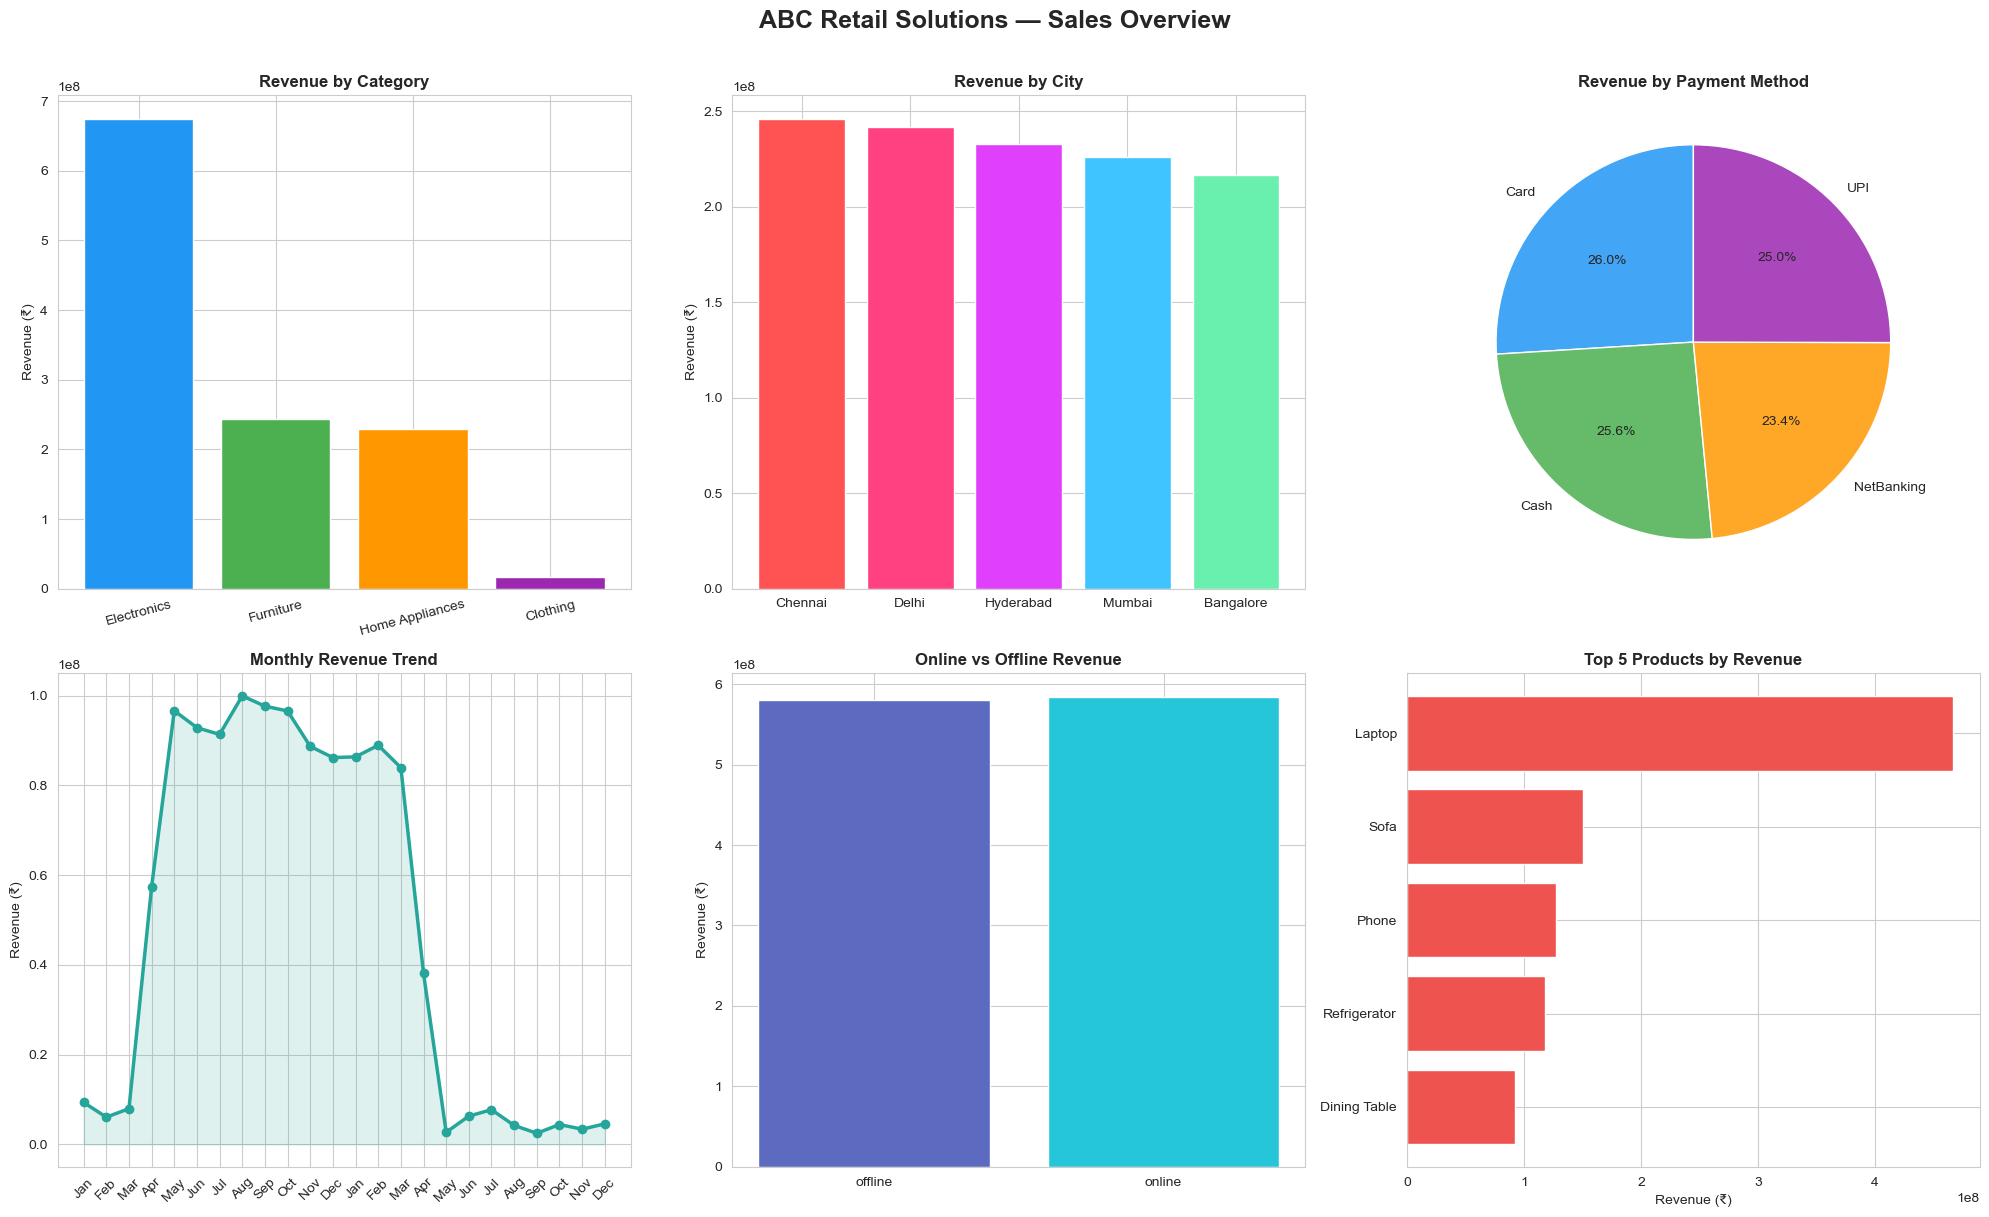

Overview chart saved.


In [33]:
# VISUALIZATION 1 — Sales Overview Dashboard

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('ABC Retail Solutions — Sales Overview', fontsize=18, fontweight='bold', y=1.01)

# 1. Revenue by Category
axes[0,0].bar(rev_by_category['Category'], rev_by_category['Total Revenue'],
              color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
axes[0,0].set_title('Revenue by Category', fontweight='bold')
axes[0,0].set_ylabel('Revenue (₹)')
axes[0,0].tick_params(axis='x', rotation=15)

# 2. Revenue by City
axes[0,1].bar(rev_by_city['City'], rev_by_city['Total Revenue'],
              color=['#FF5252','#FF4081','#E040FB','#40C4FF','#69F0AE'])
axes[0,1].set_title('Revenue by City', fontweight='bold')
axes[0,1].set_ylabel('Revenue (₹)')

# 3. Payment Method Distribution
axes[0,2].pie(rev_by_payment['revenue'], labels=rev_by_payment['payment_method'],
              autopct='%1.1f%%', startangle=90,
              colors=['#42A5F5','#66BB6A','#FFA726','#AB47BC'])
axes[0,2].set_title('Revenue by Payment Method', fontweight='bold')

# 4. Monthly Revenue Trend
axes[1,0].plot(range(len(rev_by_month)), rev_by_month['revenue'],
               marker='o', color='#26A69A', linewidth=2.5)
axes[1,0].fill_between(range(len(rev_by_month)), rev_by_month['revenue'], alpha=0.15, color='#26A69A')
axes[1,0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[1,0].set_xticks(range(len(rev_by_month)))
axes[1,0].set_xticklabels(rev_by_month['month_name'], rotation=45)
axes[1,0].set_ylabel('Revenue (₹)')

# 5. Online vs Offline
axes[1,1].bar(rev_by_channel['purchase_location'], rev_by_channel['revenue'],
              color=['#5C6BC0','#26C6DA'])
axes[1,1].set_title('Online vs Offline Revenue', fontweight='bold')
axes[1,1].set_ylabel('Revenue (₹)')

# 6. Top 5 Products
top5 = top_products.head(5)
axes[1,2].barh(top5['product_name'], top5['Total_Revenue'], color='#EF5350')
axes[1,2].set_title('Top 5 Products by Revenue', fontweight='bold')
axes[1,2].set_xlabel('Revenue (₹)')
axes[1,2].invert_yaxis()

plt.tight_layout()
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Overview chart saved.')

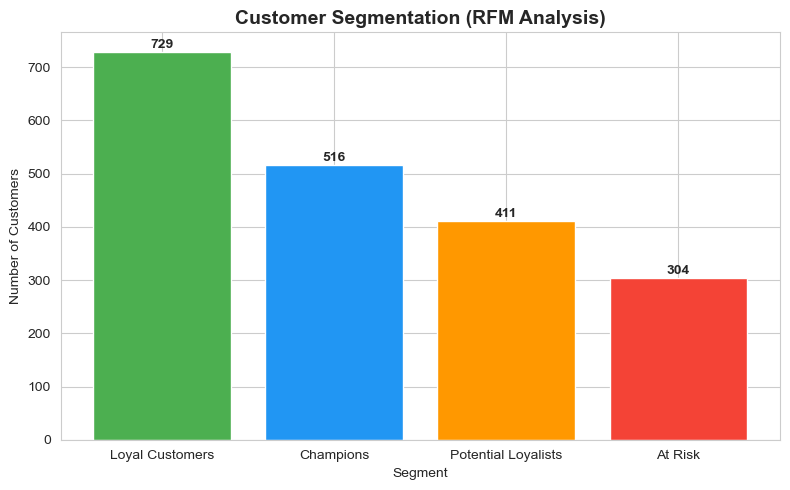

In [34]:
# VISUALIZATION 2 — RFM Segment Distribution

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_counts.index, segment_counts.values,
               color=['#4CAF50','#2196F3','#FF9800','#F44336'])
plt.title('Customer Segmentation (RFM Analysis)', fontweight='bold', fontsize=14)
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

2026-06-01 03:15:05,483 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-01 03:15:05,485 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


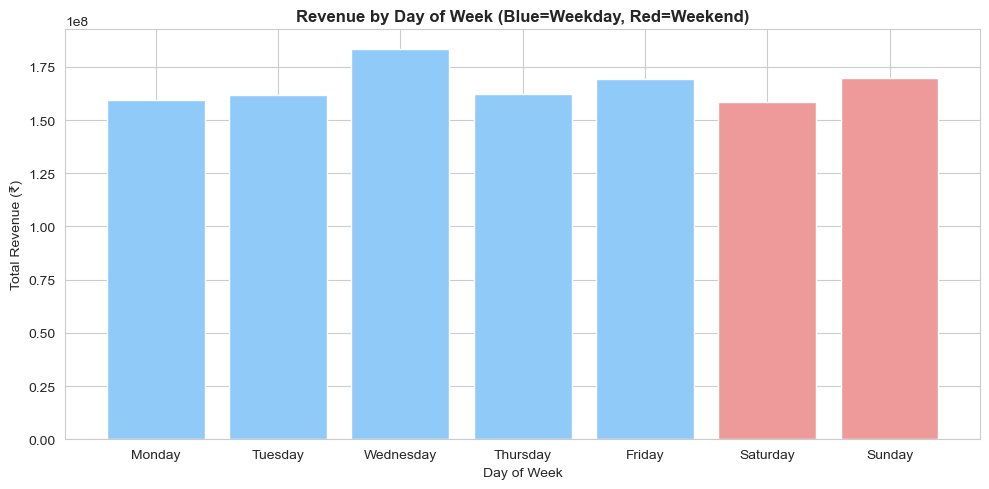

In [35]:
# VISUALIZATION 3 — Weekend vs Weekday

day_revenue = df.groupby('day_of_week')['revenue'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

colors = ['#EF9A9A' if d in ['Saturday','Sunday'] else '#90CAF9' for d in day_revenue.index]

plt.figure(figsize=(10, 5))
plt.bar(day_revenue.index, day_revenue.values, color=colors)
plt.title('Revenue by Day of Week (Blue=Weekday, Red=Weekend)', fontweight='bold')
plt.ylabel('Total Revenue (₹)')
plt.xlabel('Day of Week')
plt.tight_layout()
plt.savefig('../data/processed/revenue_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 — Save Processed Data

In [36]:
# SAVING ALL OUTPUT FILES

os.makedirs('../data/processed', exist_ok=True)

# Main cleaned dataset
df.to_csv('../data/processed/cleaned_retail_data.csv', index=False)
logger.info('Cleaned dataset saved.')

# KPI aggregates
rev_by_category.to_csv('../data/processed/kpi_revenue_by_category.csv', index=False)
rev_by_city.to_csv('../data/processed/kpi_revenue_by_city.csv', index=False)
top_products.to_csv('../data/processed/kpi_top_products.csv', index=False)
rfm.to_csv('../data/processed/rfm_segments.csv', index=False)
mom.to_csv('../data/processed/kpi_mom_growth.csv', index=False)

print('All files saved to ../data/processed/')
print(f'Final dataset shape: {df.shape}')

2026-06-01 03:15:08,860 - INFO - Cleaned dataset saved.


All files saved to ../data/processed/
Final dataset shape: (7914, 24)


---
## Section 10 — Azure Blob Storage Upload
Uploading raw and processed files to Azure Blob Storage for cloud-based scalability.

In [37]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "azure-storage-blob", "python-dotenv"])

try:
    from azure.storage.blob import BlobServiceClient
    from dotenv import load_dotenv
    import os

    # Load connection string from .env file
    load_dotenv()
    AZURE_CONNECTION_STRING = os.getenv('AZURE_CONNECTION_STRING')
    CONTAINER_NAME = 'retail-pipeline'

    if not AZURE_CONNECTION_STRING:
        raise ValueError("Connection string not found in .env file")

    def upload_to_azure(local_path, blob_name):
        client = BlobServiceClient.from_connection_string(
                    AZURE_CONNECTION_STRING)
        container = client.get_container_client(CONTAINER_NAME)
        try:
            container.create_container()
        except:
            pass  # Container already exists
        with open(local_path, 'rb') as f:
            container.upload_blob(
                name=blob_name,
                data=f,
                overwrite=True
            )
        
        print(f'Uploaded: {blob_name}')

    # Upload raw file
    upload_to_azure(
        '../data/raw/USECASE_-_Data_Engineering.xlsx',
        'raw/retail_data.xlsx'
    )

    # Upload processed files
    upload_to_azure(
        '../data/processed/cleaned_retail_data.csv',
        'processed/cleaned_retail_data.csv'
    )
    upload_to_azure(
        '../data/processed/rfm_segments.csv',
        'processed/rfm_segments.csv'
    )
    upload_to_azure(
        '../data/processed/kpi_revenue_by_category.csv',
        'processed/kpi_revenue_by_category.csv'
    )
    upload_to_azure(
        '../data/processed/kpi_top_products.csv',
        'processed/kpi_top_products.csv'
    )

    print('')
    print('All files uploaded to Azure Blob Storage!')
    print(f'Container: {CONTAINER_NAME}')
    print(f'Storage Account: neostatsretail')

except Exception as e:
    print(f'Azure upload failed: {e}')

2026-06-01 03:15:17,507 - INFO - Request URL: 'https://neostatsretail.blob.core.windows.net/retail-pipeline?restype=REDACTED'
Request method: 'PUT'
Request headers:
    'x-ms-version': 'REDACTED'
    'Accept': 'application/xml'
    'User-Agent': 'azsdk-python-storage-blob/12.29.0 Python/3.9.13 (Windows-10-10.0.26200-SP0)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': '03998345-5d3a-11f1-9521-0045e2d77712'
    'Authorization': 'REDACTED'
No body was attached to the request
2026-06-01 03:15:17,864 - INFO - Response status: 409
Response headers:
    'Content-Length': '230'
    'Content-Type': 'application/xml'
    'Server': 'Windows-Azure-Blob/1.0 Microsoft-HTTPAPI/2.0'
    'x-ms-request-id': 'b808e576-101e-0087-0846-f1b80f000000'
    'x-ms-client-request-id': '03998345-5d3a-11f1-9521-0045e2d77712'
    'x-ms-version': 'REDACTED'
    'x-ms-error-code': 'ContainerAlreadyExists'
    'Date': 'Sun, 31 May 2026 21:45:17 GMT'
2026-06-01 03:15:17,872 - INFO - Request URL: 'https://neo

Uploaded: raw/retail_data.xlsx


2026-06-01 03:15:19,732 - INFO - Response status: 409
Response headers:
    'Content-Length': '230'
    'Content-Type': 'application/xml'
    'Server': 'Windows-Azure-Blob/1.0 Microsoft-HTTPAPI/2.0'
    'x-ms-request-id': '20d226fd-001e-005f-2e46-f11fde000000'
    'x-ms-client-request-id': '04bec58f-5d3a-11f1-a821-0045e2d77712'
    'x-ms-version': 'REDACTED'
    'x-ms-error-code': 'ContainerAlreadyExists'
    'Date': 'Sun, 31 May 2026 21:45:19 GMT'
2026-06-01 03:15:19,735 - INFO - Request URL: 'https://neostatsretail.blob.core.windows.net/retail-pipeline/processed/cleaned_retail_data.csv'
Request method: 'PUT'
Request headers:
    'Content-Length': '1563731'
    'x-ms-blob-type': 'REDACTED'
    'x-ms-version': 'REDACTED'
    'Content-Type': 'application/octet-stream'
    'Accept': 'application/xml'
    'User-Agent': 'azsdk-python-storage-blob/12.29.0 Python/3.9.13 (Windows-10-10.0.26200-SP0)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': '04ed8289-5d3a-11f1-9e65-0045e2d7771

Uploaded: processed/cleaned_retail_data.csv


2026-06-01 03:15:22,727 - INFO - Response status: 409
Response headers:
    'Content-Length': '230'
    'Content-Type': 'application/xml'
    'Server': 'Windows-Azure-Blob/1.0 Microsoft-HTTPAPI/2.0'
    'x-ms-request-id': '26715309-501e-0021-3c46-f18011000000'
    'x-ms-client-request-id': '068a537d-5d3a-11f1-827f-0045e2d77712'
    'x-ms-version': 'REDACTED'
    'x-ms-error-code': 'ContainerAlreadyExists'
    'Date': 'Sun, 31 May 2026 21:45:22 GMT'
2026-06-01 03:15:22,783 - INFO - Request URL: 'https://neostatsretail.blob.core.windows.net/retail-pipeline/processed/rfm_segments.csv'
Request method: 'PUT'
Request headers:
    'Content-Length': '83857'
    'x-ms-blob-type': 'REDACTED'
    'x-ms-version': 'REDACTED'
    'Content-Type': 'application/octet-stream'
    'Accept': 'application/xml'
    'User-Agent': 'azsdk-python-storage-blob/12.29.0 Python/3.9.13 (Windows-10-10.0.26200-SP0)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': '06be896b-5d3a-11f1-8947-0045e2d77712'
    'A

Uploaded: processed/rfm_segments.csv


2026-06-01 03:15:23,296 - INFO - Response status: 409
Response headers:
    'Content-Length': '230'
    'Content-Type': 'application/xml'
    'Server': 'Windows-Azure-Blob/1.0 Microsoft-HTTPAPI/2.0'
    'x-ms-request-id': '42aa72c8-e01e-0033-0446-f1b40d000000'
    'x-ms-client-request-id': '06e4ea56-5d3a-11f1-bf62-0045e2d77712'
    'x-ms-version': 'REDACTED'
    'x-ms-error-code': 'ContainerAlreadyExists'
    'Date': 'Sun, 31 May 2026 21:45:23 GMT'
2026-06-01 03:15:23,300 - INFO - Request URL: 'https://neostatsretail.blob.core.windows.net/retail-pipeline/processed/kpi_revenue_by_category.csv'
Request method: 'PUT'
Request headers:
    'Content-Length': '122'
    'x-ms-blob-type': 'REDACTED'
    'x-ms-version': 'REDACTED'
    'Content-Type': 'application/octet-stream'
    'Accept': 'application/xml'
    'User-Agent': 'azsdk-python-storage-blob/12.29.0 Python/3.9.13 (Windows-10-10.0.26200-SP0)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': '070d82d7-5d3a-11f1-b995-0045e2d7771

Uploaded: processed/kpi_revenue_by_category.csv


2026-06-01 03:15:23,649 - INFO - Response status: 409
Response headers:
    'Content-Length': '230'
    'Content-Type': 'application/xml'
    'Server': 'Windows-Azure-Blob/1.0 Microsoft-HTTPAPI/2.0'
    'x-ms-request-id': '932a3a33-401e-007a-4046-f1876d000000'
    'x-ms-client-request-id': '07178fcd-5d3a-11f1-acd9-0045e2d77712'
    'x-ms-version': 'REDACTED'
    'x-ms-error-code': 'ContainerAlreadyExists'
    'Date': 'Sun, 31 May 2026 21:45:23 GMT'
2026-06-01 03:15:23,654 - INFO - Request URL: 'https://neostatsretail.blob.core.windows.net/retail-pipeline/processed/kpi_top_products.csv'
Request method: 'PUT'
Request headers:
    'Content-Length': '348'
    'x-ms-blob-type': 'REDACTED'
    'x-ms-version': 'REDACTED'
    'Content-Type': 'application/octet-stream'
    'Accept': 'application/xml'
    'User-Agent': 'azsdk-python-storage-blob/12.29.0 Python/3.9.13 (Windows-10-10.0.26200-SP0)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': '0743493e-5d3a-11f1-bb1d-0045e2d77712'
    

Uploaded: processed/kpi_top_products.csv

All files uploaded to Azure Blob Storage!
Container: retail-pipeline
Storage Account: neostatsretail


---
## Section 11 — Pipeline Summary

In [38]:
print('='*60)
print('PIPELINE EXECUTION COMPLETE')
print('='*60)
print(f'  Raw records ingested    : {raw_combined.shape[0]:,}')
print(f'  Final cleaned records   : {df.shape[0]:,}')
print(f'  Total Revenue           : ₹{df["revenue"].sum():,.2f}')
print(f'  Unique Customers        : {df["customer_id"].nunique():,}')
print(f'  Unique Products         : {df["product_name"].nunique():,}')
print(f'  Cities Covered          : {df["city"].nunique()}')
print(f'  Date Range              : {df["transaction_date"].min().date()} to {df["transaction_date"].max().date()}')
print('='*60)

PIPELINE EXECUTION COMPLETE
  Raw records ingested    : 8,494
  Final cleaned records   : 7,914
  Total Revenue           : ₹1,163,993,285.00
  Unique Customers        : 1,960
  Unique Products         : 10
  Cities Covered          : 5
  Date Range              : 2025-01-05 to 2026-12-04
